
# NanoGPT

Companion notebook to the [Zero To Hero](https://karpathy.ai/zero-to-hero.html) video on GPT.

**Freely modified by Vincent Runge (March 2026)**

In [263]:
# ============================================================
# Installation + imports for the notebook
# ============================================================

# External packages used in the notebook
# %pip install -q torch numpy matplotlib torchinfo torchview

# Standard library
import math
from collections import OrderedDict

# Scientific Python
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.nn import functional as F

# Model inspection / visualization
from torchinfo import summary
from torchview import draw_graph

# Device used later in the notebook
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
## (1) tinyshakespeare dataset 
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

In [266]:
# We always start with a dataset to train on. Let's download the tiny shakespeare dataset
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

zsh:1: command not found: wget


In [268]:
# read it in to inspect it
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [270]:
print("length of dataset in characters: ", len(text))

length of dataset in characters:  1115394


In [272]:
# let's look at the first 1000 characters
print(text)

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [273]:
# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)

print("vocab_size:", vocab_size)
print("vocal elements:", ''.join(chars))

vocab_size: 65
vocal elements: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


### Mapping from characters to integers

In [277]:
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

In [279]:
print(encode("$! \n gpt"))

[3, 2, 1, 0, 1, 45, 54, 58]


In [281]:
encode("Master student")

[25, 39, 57, 58, 43, 56, 1, 57, 58, 59, 42, 43, 52, 58]

In [283]:
decode(encode("Master student"))

'Master student'

In [285]:
# let's now encode the entire text dataset and store it into a torch.Tensor
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:100]) # the 100 characters we looked at earier will to the GPT look like this

torch.Size([1115394]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59])




From now one, the dataset with 1115394 characters in now a vector of integers (from 0 to 64) of length 1115394.



<font color='teal'>

___ 


Comments:

- (+) A character-level vocabulary is simple: the **vocabulary is small**, preprocessing is minimal, and the model can generate any in-vocabulary word character by character. 

- (-) A sentence contains many more characters than words or subwords: **attention becomes more expensive**. We need more characters than words for the same context.

- (-) A single character usually carries **very little meaning**, so the model must learn words from longer contexts (=> Slower learning of long-range structure) To understand a whole word, the model must combine several character tokens. We could generate "fake words" (This is what happens in practice. See below).

___ 


### Train and validation sets

In [290]:
# Let's now split up the data into train and validation sets
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
## (2) Context and target structure
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

### Context -> target understanding

In [294]:
block_size = 8
start = 0
print(train_data[start:start+block_size+1])
start = 1
print(train_data[start:start+block_size+1])

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])
tensor([47, 56, 57, 58,  1, 15, 47, 58, 47])


In [296]:
x = train_data[:block_size]
y = train_data[1:block_size+1]

___

<font color='teal'>

Comment:

A sequence of length $\texttt{block\_size+1}$ yields $\texttt{block\_size}$ training pairs
$$
(x_1)\to x_2,\quad (x_1,x_2)\to x_3,\quad \dots,\quad (x_1,\dots,x_{\texttt{block\_size}})\to x_{\texttt{block\_size}+1}.
$$

The model sees **short-context** and **longer-context**. More **sample-efficient**: one chunk of text produces many training signals. **Denser supervision** : every position contributes to the loss.

**With these pairs?** When predicting position $t$, the model must not use tokens after $t$; otherwise it would leak the answer and the training objective would be invalid. Later in the Transformer, this is enforced by the **causal mask**.

Increasing $\texttt{block\_size}$ => the model uses much longer context, it can learn longer-range dependencies.
But **much more attention cost:** self-attention scales like $O(T^2)$, so $256$ is far more expensive than $8$.

___ 

## Data preparation

In [301]:
torch.manual_seed(1337)
batch_size = 4 # how many independent sequences will we process in parallel?
block_size = 8 # what is the maximum context length for predictions?

def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])     ### start at i (4 random i in ix)
    y = torch.stack([data[i+1:i+block_size+1] for i in ix]) ### start at i+1
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

inputs:
torch.Size([4, 8])
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])
targets:
torch.Size([4, 8])
tensor([[43, 58,  5, 57,  1, 46, 43, 39],
        [53, 56,  1, 58, 46, 39, 58,  1],
        [58,  1, 58, 46, 39, 58,  1, 46],
        [17, 27, 10,  0, 21,  1, 54, 39]])


___

<font color='teal'>

As is often done in machine learning, we use **mini-batches** during training. Here, we collect 4 sequences of length 8, where 8 is the context window size. This gives 4 × 8 = 32 token-level training examples.

___


███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# (3) Bigram
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

Bigram idea: the next token depends only on the current token. So if the current token is $i$, the model learns a distribution over the next token $j$. Mathematically: $P(x_t | x_1, ..., x_{t-1}) ≈ P(x_t | x_{t-1})$. This is much simpler than a Transformer: there is no attention, no hidden state, no long-range memory.


___ 

$\texttt{\_init\_}$: Creates the bigram table.
    
$\texttt{forward}$: Given current tokens, returns next-token logits and optionally computes the training loss.

$\texttt{generate}$: Produces text by random sampling.
    
$\texttt{generate\_deterministic}$: Produces text by greedy decoding.

___

In [308]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.token_embedding_table(idx) 
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            logits, loss = self(idx)
            logits = logits[:, -1, :] 
            probs = F.softmax(logits, dim=-1) 
            idx_next = torch.multinomial(probs, num_samples=1) 
            idx = torch.cat((idx, idx_next), dim=1) 
        return idx

    def generate_deterministic(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            logits, loss = self(idx)
            logits = logits[:, -1, :]
            idx_next = torch.argmax(logits, dim=-1, keepdim=True) 
            idx = torch.cat((idx, idx_next), dim=1) 
        return idx


___

<font color='teal'>
    
### a) Notations

We have two tensors $x \in \{0,\dots,V-1\}^{B \times T},
\, y \in \{0,\dots,V-1\}^{B \times T}$, where:

- $B$ is the batch size,
- $T$ is the block size,
- $V$ is the vocabulary size.

For each batch element $b$ and time step $t$, $x_{b,t} = \text{current token}$ and  $y_{b,t} = \text{next token}$.


### b) Bigram parametrization

The model learns a matrix $W \in \mathbb{R}^{V \times V}$. For a given current token $i$, the row $W_{i,:}$ contains the scores for all possible next tokens.  Thus, for the entry $x_{b,t}$, the model outputs the logit vector $z_{b,t,:} = W_{x_{b,t},:}$, or, for each candidate next token $j$, $z_{b,t,j} = W_{x_{b,t},j}$.

### c) From logits to probabilities

The softmax transforms these scores into probabilities:

$$
p_{b,t,j}
=
P\bigl(Y=j \mid X=x_{b,t}\bigr)
=
\frac{e^{z_{b,t,j}}}{\sum_{k=1}^V e^{z_{b,t,k}}}.
$$

In particular, the probability assigned to the true next token $y_{b,t}$ is

$$
p_{b,t,y_{b,t}}
=
\frac{e^{z_{b,t,y_{b,t}}}}{\sum_{k=1}^V e^{z_{b,t,k}}}.
$$



<font color='teal'>
    
### d) Loss for one position

For one pair $\bigl(x_{b,t},y_{b,t}\bigr)$, the cross-entropy loss is

$$
\mathcal{L}_{b,t}
=
-\log p_{b,t,y_{b,t}}.
$$

By replacing the softmax formula, this becomes

$$
\mathcal{L}_{b,t}
=
-\log\left(
\frac{e^{z_{b,t,y_{b,t}}}}{\sum_{k=1}^V e^{z_{b,t,k}}}
\right)
=
- z_{b,t,y_{b,t}} + \log \sum_{k=1}^V e^{z_{b,t,k}}.
$$

So the loss is small when the model assigns a large score to the correct next token compared with the others.

### e) Batch loss

The model does not train on a single pair $\bigl(x_{b,t},y_{b,t}\bigr)$, but on all $B \times T$ pairs in the batch at once. The batch loss is therefore the average

$$
\mathcal{L}
=
\frac{1}{BT}
\sum_{b=1}^B \sum_{t=1}^T \mathcal{L}_{b,t}
=
\frac{1}{BT}
\sum_{b=1}^B \sum_{t=1}^T
-\log p_{b,t,y_{b,t}}.
$$

This is the key link with batch training:

- each position $(b,t)$ is one training example,
- the loss averages the errors over all positions in all sequences,
- gradient descent updates $W$ using this average signal.

Why the reshaping in the code?  The tensor of logits has shape $(B,T,V)$ because for each pair $(b,t)$ the model outputs a vector of length $V$. The target tensor has shape $(B,T)$ PyTorch expects cross-entropy inputs of shape $(N,V)$ and $(N)$ with one row per training example.  
Here the number of examples is  $N = B T$.

So the code reshapes the tensors as:

```python
B, T, C = logits.shape
logits = logits.view(B*T, C)
targets = targets.view(B*T)
loss = F.cross_entropy(logits, targets)

###  One step - no learning

In [314]:
xb, yb = get_batch('train')
m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)

torch.Size([32, 65])
tensor(4.8549, grad_fn=<NllLossBackward0>)


___

<font color='teal'>

We use here only one batch: $\texttt{xb, yb = get\_batch('train')}$ and no optimization step. The loss is of order $\texttt{log(vocab\_size)}$.


In [317]:
-np.log(1/vocab_size)

4.174387269895637

###  Generating a sequence (of size nb)

In [321]:
current_token = ' '
# index (from 0 to 64 of the chosen token)
idx = torch.tensor([[stoi[current_token]]], dtype=torch.long)   # shape (1,1)
print(idx)

# generation of 20 tokens
res = m.generate(idx = idx, max_new_tokens= 10)
print("result with the integers/token: ", res)
print("result with the characters: ", decode(res[0].tolist())) # 1 dim array (batch size 1)

tensor([[1]])
result with the integers/token:  tensor([[ 1, 34, 25, 28, 18, 57, 28, 20, 31, 37, 13]])
result with the characters:   VMPFsPHSYA


If we generate the next token with a deterministic choice (no more multinomial guess):

In [324]:
res = m.generate_deterministic(idx = idx, max_new_tokens= 200)
print(res)
print(decode(res[0].tolist()))

tensor([[ 1, 29, 27, 21, 16, 43, 18, 61, 49, 36, 58, 34, 39, 44, 27, 21, 16, 43,
         18, 61, 49, 36, 58, 34, 39, 44, 27, 21, 16, 43, 18, 61, 49, 36, 58, 34,
         39, 44, 27, 21, 16, 43, 18, 61, 49, 36, 58, 34, 39, 44, 27, 21, 16, 43,
         18, 61, 49, 36, 58, 34, 39, 44, 27, 21, 16, 43, 18, 61, 49, 36, 58, 34,
         39, 44, 27, 21, 16, 43, 18, 61, 49, 36, 58, 34, 39, 44, 27, 21, 16, 43,
         18, 61, 49, 36, 58, 34, 39, 44, 27, 21, 16, 43, 18, 61, 49, 36, 58, 34,
         39, 44, 27, 21, 16, 43, 18, 61, 49, 36, 58, 34, 39, 44, 27, 21, 16, 43,
         18, 61, 49, 36, 58, 34, 39, 44, 27, 21, 16, 43, 18, 61, 49, 36, 58, 34,
         39, 44, 27, 21, 16, 43, 18, 61, 49, 36, 58, 34, 39, 44, 27, 21, 16, 43,
         18, 61, 49, 36, 58, 34, 39, 44, 27, 21, 16, 43, 18, 61, 49, 36, 58, 34,
         39, 44, 27, 21, 16, 43, 18, 61, 49, 36, 58, 34, 39, 44, 27, 21, 16, 43,
         18, 61, 49]])
 QOIDeFwkXtVafOIDeFwkXtVafOIDeFwkXtVafOIDeFwkXtVafOIDeFwkXtVafOIDeFwkXtVafOIDeFwkXtVaf

The probability associated to each next token:

In [328]:
current_token = '.'
idx = torch.tensor([[stoi[current_token]]], dtype=torch.long)   # shape (1,1)
logits, _ = m(idx)         
logits_last = logits[:, -1, :] 
probs = F.softmax(logits_last, dim=-1)  

print('-------------------------------------------------------------------------------------------')

print(f"Current token: {current_token}") # max probability and corresponding token
max_prob, max_idx = torch.max(probs, dim=-1)
print("Most likely next token:")
print(f"token = '{itos[max_idx.item()]}'")
print(f"max probability = {max_prob.item():.6f}")


print("\nProbabilities for the next token:")
for i, p in enumerate(probs[0]):
    print(f"P(next = '{itos[i]}' | current = '{current_token}') = {p.item():.6f}")

print('-------------------------------------------------------------------------------------------')

-------------------------------------------------------------------------------------------
Current token: .
Most likely next token:
token = 'f'
max probability = 0.056473

Probabilities for the next token:
P(next = '
' | current = '.') = 0.004079
P(next = ' ' | current = '.') = 0.006772
P(next = '!' | current = '.') = 0.007959
P(next = '$' | current = '.') = 0.002276
P(next = '&' | current = '.') = 0.001974
P(next = ''' | current = '.') = 0.012930
P(next = ',' | current = '.') = 0.028579
P(next = '-' | current = '.') = 0.016909
P(next = '.' | current = '.') = 0.014985
P(next = '3' | current = '.') = 0.002966
P(next = ':' | current = '.') = 0.047464
P(next = ';' | current = '.') = 0.004153
P(next = '?' | current = '.') = 0.013241
P(next = 'A' | current = '.') = 0.020382
P(next = 'B' | current = '.') = 0.004941
P(next = 'C' | current = '.') = 0.006211
P(next = 'D' | current = '.') = 0.013472
P(next = 'E' | current = '.') = 0.006820
P(next = 'F' | current = '.') = 0.017139
P(next = 'G' |

### Iterations with bigram (training the model)

Last training loss: 2.5450596809387207
Last validation loss: 2.495612173080444


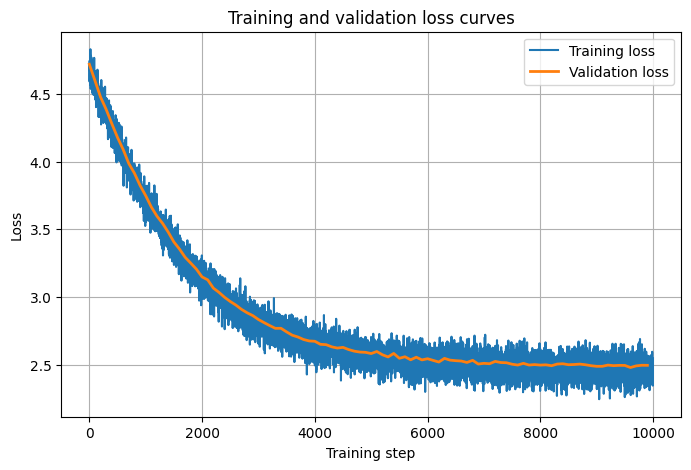

In [332]:
bigram = BigramLanguageModel(vocab_size)

# optimizer
optimizer = torch.optim.AdamW(bigram.parameters(), lr=1e-3)
train_losses = []
val_losses = []
eval_steps = []

batch_size = 32

@torch.no_grad()
def estimate_split_loss(model, split, n_batches=100):
    model.eval()
    losses = []
    for _ in range(n_batches):
        xb, yb = get_batch(split)
        _, loss = model(xb, yb)
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)

for step in range(10000):
    # training step
    xb, yb = get_batch('train')
    logits, loss = bigram(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    # store training loss at every step
    train_losses.append(loss.item())

    # evaluate from time to time on validation set
    if step % 100 == 0:
        val_loss = estimate_split_loss(bigram, 'val', n_batches=100)
        val_losses.append(val_loss)
        eval_steps.append(step)

print("Last training loss:", train_losses[-1])
print("Last validation loss:", val_losses[-1])

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training loss")
plt.plot(eval_steps, val_losses, label="Validation loss", linewidth=2)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Training and validation loss curves")
plt.grid(True)
plt.legend()
plt.show()

In [333]:
nb = 500

current_token = 'z'
#position of the chosen token
firstToken = torch.tensor([[stoi[current_token]]], dtype=torch.long)   # shape (1,1)

res = bigram.generate(idx = firstToken, max_new_tokens= nb)
print(decode(res[0].tolist()))


z bou? s-efuril win d fiouby fon, asheche MELor?
TZCENED theean G'sthith widangushenen, u athoonchar

Aieavece I bu p?
Sthayolste
Thr ld wen thety' lle, touganuitKE 'Wout atqur se tharere gn.
YClowisl onOng mpprrde fofan'shano,
Q! by his moor, heatis, trmbuty, wo won o,


Wivit t,

An.
BEDUShea
IDokliseathime hethen s winoirepe g,
I.
orevo ncay! h cowoot'Engerdicow UDUS:

CELLUENILag t s sp, t emmom'd thatheny-faweallove waby angeal tethexperd mes thacot aralerust
S:
Hef, bu.
T:

Whe anersththal 


In [334]:
res = bigram.generate_deterministic(idx = firstToken, max_new_tokens= nb)
print(decode(res[0].tolist()))


ze the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the th


In [335]:
current_token = '.'
idx = torch.tensor([[stoi[current_token]]], dtype=torch.long)   # shape (1,1)
logits, _ = bigram(idx)         
logits_last = logits[:, -1, :] 
probs = F.softmax(logits_last, dim=-1)  

print('-------------------------------------------------------------------------------------------')

print(f"Current token: {current_token}") # max probability and corresponding token
max_prob, max_idx = torch.max(probs, dim=-1)
print("Most likely next token:")
print(f"token = '{itos[max_idx.item()]}'")
print(f"max probability = {max_prob.item():.6f}")


print("\nProbabilities for the next token:")
for i, p in enumerate(probs[0]):
    print(f"P(next = '{itos[i]}' | current = '{current_token}') = {p.item():.6f}")

print('-------------------------------------------------------------------------------------------')

-------------------------------------------------------------------------------------------
Current token: .
Most likely next token:
token = '
'
max probability = 0.837395

Probabilities for the next token:
P(next = '
' | current = '.') = 0.837395
P(next = ' ' | current = '.') = 0.136659
P(next = '!' | current = '.') = 0.000415
P(next = '$' | current = '.') = 0.000443
P(next = '&' | current = '.') = 0.000333
P(next = ''' | current = '.') = 0.008977
P(next = ',' | current = '.') = 0.000210
P(next = '-' | current = '.') = 0.002022
P(next = '.' | current = '.') = 0.000662
P(next = '3' | current = '.') = 0.000209
P(next = ':' | current = '.') = 0.000146
P(next = ';' | current = '.') = 0.001012
P(next = '?' | current = '.') = 0.000094
P(next = 'A' | current = '.') = 0.000273
P(next = 'B' | current = '.') = 0.000456
P(next = 'C' | current = '.') = 0.000059
P(next = 'D' | current = '.') = 0.000062
P(next = 'E' | current = '.') = 0.000108
P(next = 'F' | current = '.') = 0.000305
P(next = 'G' |

___

<font color='teal'>
    
**Comments:** With a corpus, you can also count how often token (i) is followed by token (j): $C_{ij} = \#\{, i \to j \}$. Then you normalize each row: $\hat P(j \mid i) = \frac{C_{ij}}{\sum_k C_{ik}}$. So this method is:

- direct
- closed form
- based purely on observed frequencies
- usually gives zero for unseen pairs unless you add smoothing


In the notebook, the “bigram” model learns a matrix of logits $W \in \mathbb{R}^{V \times V}$ then applies a softmax: $P(j \mid i) = \mathrm{softmax}(W_i)_j$. The entries of $W$ are learned by minimizing cross-entropy with gradient descent. So the neural version is different because:

* it does optimization instead of direct counting
* it learns logits, not probabilities directly
* softmax makes probabilities strictly positive
* with finite training steps, minibatches, and optimizer effects, it may not exactly match the raw count estimate

<font color='red'>
    
## We compare the bigram approach with the count data approach

In [339]:
# ------------------------------------------------------------
# Count-based bigram model
# ------------------------------------------------------------

def build_bigram_counts(data, vocab_size):
    counts = torch.zeros((vocab_size, vocab_size), dtype=torch.float32)
    x = data[:-1]
    y = data[1:]
    counts.index_put_((x, y), torch.ones(len(x), dtype=torch.float32), accumulate=True)
    return counts

def count_loss_on_data(counts, data, alpha=0.0):
    """
    Exact negative log-likelihood on a whole sequence `data`.
    The model is built from training counts.
    alpha=0.0 -> no smoothing
    alpha=1.0 -> Laplace smoothing
    """
    x = data[:-1]
    y = data[1:]

    row_totals = counts.sum(dim=1)  # total count for each previous token

    numerators = counts[x, y] + alpha
    denominators = row_totals[x] + alpha * counts.size(1)

    if alpha == 0.0 and torch.any(numerators == 0):
        return float("inf")

    probs = numerators / denominators
    loss = -torch.log(probs).mean().item()
    return loss

# ------------------------------------------------------------
# Build on train_data
# ------------------------------------------------------------

counts = build_bigram_counts(train_data, vocab_size)

# ------------------------------------------------------------
# Evaluate on val_data
# ------------------------------------------------------------

raw_count_val_loss = count_loss_on_data(counts, val_data, alpha=0.0)
smoothed_count_val_loss = count_loss_on_data(counts, val_data, alpha=1.0)

print("Count validation loss on full val_data (raw, no smoothing):", raw_count_val_loss)
print("Count validation loss on full val_data (Laplace smoothing, alpha=1):", smoothed_count_val_loss)
print("Trained neural bigram validation loss:", val_losses[-1])


Count validation loss on full val_data (raw, no smoothing): inf
Count validation loss on full val_data (Laplace smoothing, alpha=1): 2.481889247894287
Trained neural bigram validation loss: 2.495612173080444


___

<font color='teal'>
    
### Laplace smoothing and the role of $\alpha$

In the count-based bigram model, we estimate the probability of seeing token $j$ after token $i$ by using the observed counts: $P(j \mid i) = \frac{C_{ij}}{\sum_k C_{ik}}$ where $C_{ij}$ is the number of times $j$ follows $i$ in the training data. The problem is that if a bigram $(i,j)$ never appears in the training set, then $C_{ij}=0$, so the model assigns $P(j \mid i)=0$. This is problematic on validation data, because if such a bigram appears there, the loss contains $-\log(0)$ which is infinite.

To avoid this, we use **Laplace smoothing**. The idea is to add a small positive number $\alpha$ to every count:
$$
P(j \mid i) = \frac{C_{ij} + \alpha}{\sum_k C_{ik} + \alpha V},
$$
where $V$ is the vocabulary size.

- If $\alpha = 0$, there is **no smoothing**, and unseen bigrams still get probability \(0\).
- If $\alpha = 1$, this is the standard **Laplace smoothing**.
- More generally, any $\alpha > 0$ ensures that every bigram has a strictly positive probability.

So $\alpha$ controls how much probability mass we give to unseen events:
- a **small $\alpha$** keeps the model close to the raw counts,
- a **larger $\alpha$** makes the distribution more uniform.


███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# (4) Self-attention
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

### Averaging (bag of words)

 = We do a matrix multiplication for getting a weighted aggregation

In [345]:
B,T,C = 4,8,2 # batch, time, channels
x = torch.randn(B,T,C)
wei = torch.tril(torch.ones(T, T))
wei = wei / wei.sum(1, keepdim=True)
print(wei)
xbow = wei @ x 

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])


In [346]:
print("First batch item x[0]: ")
print(x[0])
print("First batch transformed item xbow[0]: ")
print(xbow[0])



First batch item x[0]: 
tensor([[ 2.3100,  1.5374],
        [ 0.3777,  1.4750],
        [ 0.0646,  1.3367],
        [ 0.0132, -2.0477],
        [-0.9039, -1.7483],
        [ 1.6187,  1.2159],
        [-0.4018,  0.5623],
        [-0.1308,  0.2980]])
First batch transformed item xbow[0]: 
tensor([[2.3100, 1.5374],
        [1.3439, 1.5062],
        [0.9174, 1.4497],
        [0.6914, 0.5754],
        [0.3723, 0.1106],
        [0.5801, 0.2948],
        [0.4398, 0.3331],
        [0.3685, 0.3287]])


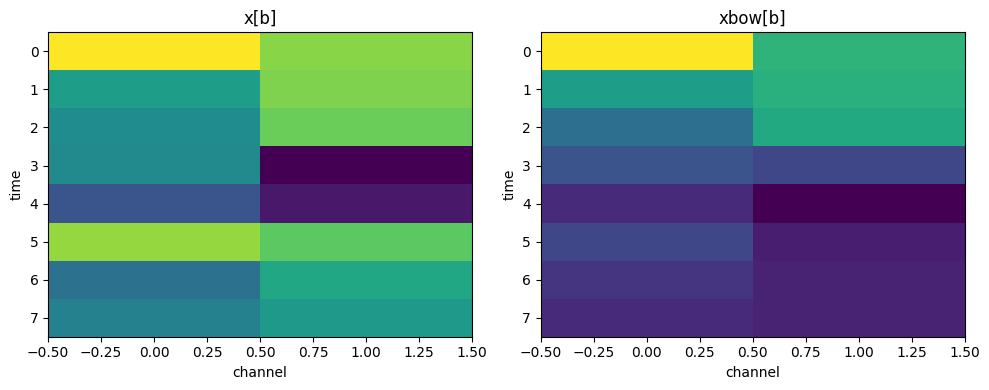

In [347]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(x[0].detach().numpy(), aspect='auto')
axes[0].set_title("x[b]")
axes[0].set_xlabel("channel")
axes[0].set_ylabel("time")

axes[1].imshow(xbow[0].detach().numpy(), aspect='auto')
axes[1].set_title("xbow[b]")
axes[1].set_xlabel("channel")
axes[1].set_ylabel("time")

plt.tight_layout()
plt.show()

### Averaging using Softmax

In [349]:
tril = torch.tril(torch.ones(T, T))
print(tril) # triangular lower
wei = torch.zeros((T,T))
print(wei)
wei = wei.masked_fill(tril == 0, float('-inf'))
print(wei)
weiSoft = F.softmax(wei, dim=-1)
print(weiSoft)
xbowSoft = wei @ x
torch.allclose(xbow, xbowSoft)

tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])
tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0.,

False

We defined logits/weights then used inside a softmax to generate the same bag of word matrix. This matrix:

In [351]:
print(wei)

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


can be much more expressive to modify the current token from its previous context.

<font color='teal'>

Comments:
    
Softmax uses exponentials: $\text{softmax}(z_i)=\frac{e^{z_i}}{\sum_j e^{z_j}}$. If $z_i=-\infty$, then $e^{z_i}=0$, so its softmax probability is exactly $0$.

Uniform averaging treats every past token as equally relevant (often one previous token is much more informative than another). Self-attention fixes this by learning **data-dependent weights**. Instead of averaging uniformly, each position computes which past positions matter most, and then aggregates their values accordingly.

 
</font>

### Self-attention structure

Given
- $x \in \mathbb{R}^{B \times T \times C}$
- $q = \mathrm{query}(x) \in \mathbb{R}^{B \times T \times \text{head\_size}}$
- $k = \mathrm{key}(x) \in \mathbb{R}^{B \times T \times \text{head\_size}}$
- $v = \mathrm{value}(x) \in \mathbb{R}^{B \times T \times \text{head\_size}}$


A useful interpretation is:
- **Query (Q):** what the current position is looking for;
- **Key (K):** what each position offers / how it can be matched;
- **Value (V):** the actual content that gets passed along once a match is made.


the raw attention scores are $\mathrm{wei} = q \, k^\top$, more precisely, for each batch index $b$,
$$
\mathrm{wei}[b] = q[b] \, k[b]^\top
$$

so entrywise, $\mathrm{wei}[b,i,j] = \sum_{d=1}^{\text{head\_size}} q[b,i,d]\,k[b,j,d]$.

Then the causal mask is applied:

$$
\mathrm{wei}[b,i,j] =
\begin{cases}
\mathrm{wei}[b,i,j], & j \le i,\\
-\infty, & j > i.
\end{cases}
$$

Then softmax is applied on the last dimension:

$$
\mathrm{wei}[b,i,j]
=
\frac{\exp(\mathrm{wei}[b,i,j])}{\sum_{m=0}^{T-1}\exp(\mathrm{wei}[b,i,m])}.
$$

Finally, the output is $\mathrm{out} = \mathrm{wei}\, v$, that is, for each batch index $b$ and time index $i$,

$$
\mathrm{out}[b,i,:]
=
\sum_{j=0}^{T-1} \mathrm{wei}[b,i,j]\, v[b,j,:].
$$

Because of the causal mask, this is really $\mathrm{out}[b,i,:] =\sum_{j=0}^{i} \mathrm{wei}[b,i,j]\, v[b,j,:]$.

In [358]:
torch.manual_seed(1337)

B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)
print(x)

tensor([[[ 0.1808, -0.0700, -0.3596,  ..., -0.8016,  1.5236,  2.5086],
         [-0.6631, -0.2513,  1.0101,  ...,  1.5333,  1.6097, -0.4032],
         [-0.8345,  0.5978, -0.0514,  ..., -0.4370, -1.0012, -0.4094],
         ...,
         [-0.8961,  0.0662, -0.0563,  ...,  2.1382,  0.5114,  1.2191],
         [ 0.1910, -0.3425,  1.7955,  ...,  0.3699, -0.5556, -0.3983],
         [-0.5819, -0.2208,  0.0135,  ..., -1.9079, -0.5276,  1.0807]],

        [[ 0.4562, -1.0917, -0.8207,  ...,  0.0512, -0.6576, -2.5729],
         [ 0.0210,  1.0060, -1.2492,  ...,  0.7859, -1.1501,  1.3132],
         [ 2.2007, -0.2195,  0.5427,  ..., -0.6445,  1.0834, -0.7995],
         ...,
         [ 0.3091,  1.1661, -2.1821,  ...,  0.6151,  0.6763,  0.6228],
         [ 0.0943, -0.3156,  0.7850,  ..., -1.5735,  1.3876,  0.7251],
         [ 0.6455, -0.3313, -1.0390,  ...,  0.0895, -0.3748, -0.4781]],

        [[-0.6067,  1.8328,  0.2931,  ...,  1.0041,  0.8656,  0.1688],
         [-0.2352, -0.2586,  0.0131,  ...,  0

In [359]:
# let's see a single Head perform self-attention
head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)
k = key(x)   # (B, T, 16)
q = query(x) # (B, T, 16)
wei =  q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)
tril = torch.tril(torch.ones(T, T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)

v = value(x)
out = wei @ v
out.shape

torch.Size([4, 8, 16])

In [361]:
wei

tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
         [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
         [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
         [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],

        [[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1687, 0.8313, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2477, 0.0514, 0.7008, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.4410, 0.0957, 0.3747, 0.0887, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0069, 0.0456, 0.0300, 0.7748, 0.1427, 0.0000, 0.0000, 0.0000],
         [0.0660, 0.089

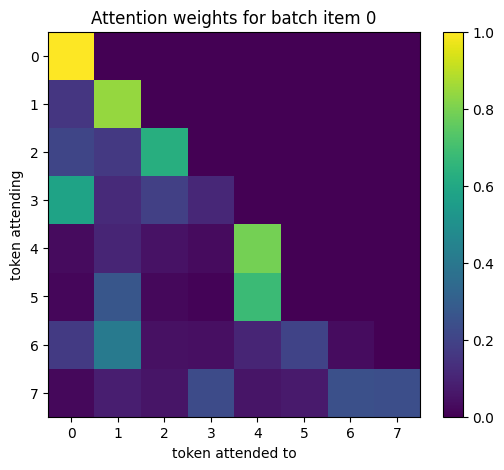

In [362]:

plt.figure(figsize=(6,5))
plt.imshow(wei[0].detach().numpy(), aspect='auto')
plt.colorbar()
plt.xlabel("token attended to")
plt.ylabel("token attending")
plt.title("Attention weights for batch item 0")
plt.show()

**In “scaled” attention**, wei is multiplied by `1 / sqrt(head_size)`. If the entries of Q and K have unit variance, this scaling keeps the attention scores in `wei` at roughly unit variance as well, preventing the `softmax` from becoming too saturated.

In [365]:
k = torch.randn(B,T,head_size)
q = torch.randn(B,T,head_size)
wei_kq1 = q @ k.transpose(-2, -1) # V1 bad
wei_kq2 = q @ k.transpose(-2, -1) * head_size**-0.5  # V2 good

In [366]:
k.var()

tensor(1.0449)

In [367]:
q.var()

tensor(1.0700)

In [368]:
print(wei_kq1.var(), wei_kq2.var())

tensor(17.4690) tensor(1.0918)


In [369]:
torch.softmax(wei_kq1[0,0,:], dim=-1) # gets too peaky

tensor([9.9429e-01, 3.3921e-07, 1.8863e-03, 1.1654e-03, 3.9907e-05, 2.5497e-03,
        1.9299e-05, 5.1578e-05])

In [370]:
torch.softmax(wei_kq2[0,0,:], dim=-1)

tensor([0.5337, 0.0129, 0.1114, 0.0987, 0.0425, 0.1201, 0.0354, 0.0453])

___

<font color='teal'>

Attention alone has no notion of order: it treats the sequence as a set of vectors. Without positional information, the model cannot distinguish different orderings of the same tokens.

In the full GPT model, positional information is added here:
$x = tok\_emb + pos\_emb.$ So the token embedding and the position embedding are summed before the Transformer blocks.

___


</font>


After passing through the transformer layers, the model outputs a probability distribution for the next token. The loss over the training data is the cross-entropy
$$
\mathcal{L}(\theta)
=
-\frac{1}{M}\sum_{n=1}^M \sum_{t=1}^{T_n}
\log p_\theta\bigl(x_{t+1}^{(n)} \mid x_{\le t}^{(n)}\bigr).
$$

This loss depends on the attention weights, hence on the matrices $W_Q$, $W_K$, and $W_V$. During training, **backpropagation** computes the gradients of the loss with respect to all these parameters, and the optimizer updates them to reduce the prediction error.

So, self-attention is trained **indirectly**: it learns how to attend to relevant previous tokens because this helps minimize the language-model loss on the training data.

___

<font color='teal'>
    
## Parameters in one attention head

Each head has three learned linear maps:

- Key: $W_K \in \mathbb{R}^{64 \times 16}$
- Query: $W_Q \in \mathbb{R}^{64 \times 16}$
- Value: $W_V \in \mathbb{R}^{64 \times 16}$

Since `bias=False` in the notebook, each matrix has $64 \times 16 = 1024$ parameters. So for **one head**: $1024 + 1024 + 1024 = 3072$ parameters.

## Parameters in the whole multi-head attention module

There are $4$ heads, so the total for all $K,Q,V$ projections is $4 \times 3072 = 12288$.

Then there is the final output projection
$$
W_O : \mathbb{R}^{64} \to \mathbb{R}^{64},
$$
implemented by `nn.Linear(64, 64)`, which has $64 \times 64 + 64 = 4096 + 64 = 4160$ parameters, because this layer **does include a bias**.

Therefore, the total number of trainable parameters in the **self-attention module of one Transformer block** is

$$
12288 + 4160 = 16448.
$$

## Final answer

- **$d_k = 16$**
- **one attention head:** $3072$ parameters
- **all 4 heads together (without output projection):** $12288$ parameters
- **full multi-head self-attention block (with output projection):** $16448$ parameters

Also note: the **mask** and the factor $1/\sqrt{d_k}$ introduce **no trainable parameters**.

___


███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# (5) Normalization Layer 
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

In [378]:
class LayerNorm1d: # (used to be BatchNorm1d)

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

  def __call__(self, x):
    # calculate the forward pass
    xmean = x.mean(1, keepdim=True) # batch mean
    xvar = x.var(1, keepdim=True) # batch variance
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

torch.manual_seed(1337)
module = LayerNorm1d(100)

In [379]:
x = torch.randn(32, 100) # batch size 32 of 100-dimensional vectors
print(x[:,0])
x[:,0].mean(), x[:,0].std() # mean,std of one feature across all batch inputs

tensor([ 0.1808,  0.0315,  0.0183,  0.6762,  0.0933,  1.6730,  1.2089,  0.3049,
        -0.9579, -0.3731,  0.3338, -2.0602, -0.2247, -1.7352,  0.7943, -0.4675,
         0.1321,  1.2762, -0.0336,  0.0540,  1.1173,  0.5901,  0.4418, -0.3025,
        -0.2498,  1.4978,  1.4311,  0.1452,  0.5343, -1.6462, -0.2266,  0.1956])


(tensor(0.1392), tensor(0.8899))

In [380]:
x = module(x)
x[0,:].mean(), x[0,:].std() # mean,std of a single input from the batch, of its features

(tensor(2.3842e-09), tensor(1.0000))

<font color='teal'>

After normalization, $x_{\text{hat}}=\frac{x-\mu}{\sqrt{\sigma^2+\varepsilon}}$, the parameters $\gamma$ and $\beta$ apply a learned affine transformation: $y = \gamma \odot x_{\text{hat}} + \beta$.

</font>

███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# (6) Full  code
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

<font color='teal'>

# Summary

The full pipeline is:

1. input token indices,
2. token embeddings,
3. positional embeddings,
4. stack of 4 Transformer blocks,
5. final normalization,
6. linear projection to vocabulary logits,
7. softmax and cross-entropy loss for next-token prediction.

With your hyperparameters:

- each token is represented in dimension $64$,
- attention uses $4$ heads,
- each head has dimension $d_k = 16$
- the model processes batches of 16 sequences,
- each sequence has maximum length 32.

<font color='blue'>

In [387]:
# hyperparameters
batch_size = 16 # how many independent sequences will we process in parallel?
block_size = 32 # what is the maximum context length for predictions? #### it was 32
max_iters = 5000
eval_interval = 100
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 64
n_head = 4
n_layer = 4
dropout = 0.0
# ---------------------------------------------------------

torch.manual_seed(1337)

# wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

# ---------------------------------------------------------


# Train and test splits
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

# ---------------------------------------------------------

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

# ---------------------------------------------------------

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out

# ---------------------------------------------------------


class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

# ---------------------------------------------------------


class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

# super simple nanoGPT model
class nanoGPT(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

model = nanoGPT()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)



0.209729 M parameters


step 0: train loss 4.4116, val loss 4.4022
step 100: train loss 2.6568, val loss 2.6670
step 200: train loss 2.5090, val loss 2.5058
step 300: train loss 2.4196, val loss 2.4336
step 400: train loss 2.3500, val loss 2.3562
step 500: train loss 2.2967, val loss 2.3133
step 600: train loss 2.2408, val loss 2.2499
step 700: train loss 2.2048, val loss 2.2184
step 800: train loss 2.1633, val loss 2.1866
step 900: train loss 2.1239, val loss 2.1497
step 1000: train loss 2.1025, val loss 2.1291
step 1100: train loss 2.0685, val loss 2.1171
step 1200: train loss 2.0376, val loss 2.0786
step 1300: train loss 2.0253, val loss 2.0642
step 1400: train loss 1.9931, val loss 2.0375
step 1500: train loss 1.9692, val loss 2.0309
step 1600: train loss 1.9628, val loss 2.0478
step 1700: train loss 1.9400, val loss 2.0119
step 1800: train loss 1.9086, val loss 1.9958
step 1900: train loss 1.9058, val loss 1.9844
step 2000: train loss 1.8849, val loss 1.9956
step 2100: train loss 1.8699, val loss 1.9734


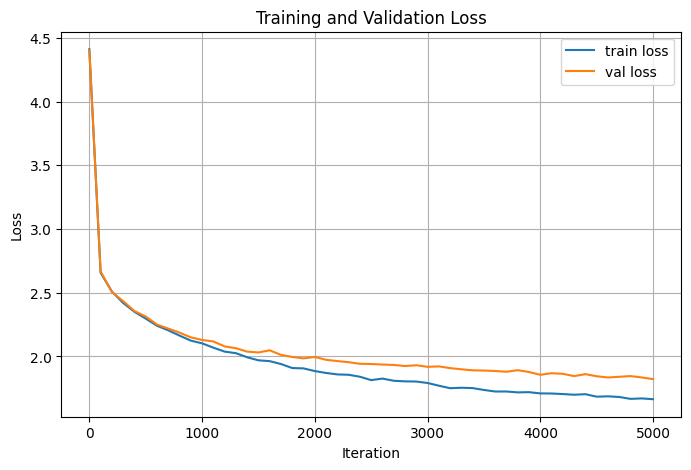


Flie?

WASICENS:
You hurse, by it creath to there. This ibe
You the sea it; and satell in rone to themselarda of this Mutration?
With.

ARCHIORD:
Ga, these that, will Gest is not dies:- Mear;
What a g


In [393]:
train_losses = []
val_losses = []
eval_steps = []

for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        train_losses.append(losses['train'].item() if hasattr(losses['train'], "item") else losses['train'])
        val_losses.append(losses['val'].item() if hasattr(losses['val'], "item") else losses['val'])
        eval_steps.append(iter)

        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

# plot
plt.figure(figsize=(8, 5))
plt.plot(eval_steps, train_losses, label="train loss")
plt.plot(eval_steps, val_losses, label="val loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=200)[0].tolist()))


In [399]:

# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=500)[0].tolist()))


And well a carer'd eyre the gentry will daught seak up the rey.

POLINI:
A everson:
Thel as us at not; do spon his see:
And who trupper; and throught altrough,
Oncead, and if I may Crance, wwife that broanst looke:;
Is no would and sape, but all
on swome make helavour,
As cout; so poison;
And Is a madie my brefore hildsbrenger.

PORY:
Yet my nourtune: at not mark I have not
Is am a brotesing me an mady compous'd that him;
Ouch the tartue to hou stand was babsom! and now thing the plidles up that


In [404]:
start_text = 'What authority '
context = torch.tensor([[stoi[ch] for ch in start_text]], dtype=torch.long)

print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))

What authority sure courself to stancious speaken:
And thus insure thy earth, to plartes no mune in en shall follous,
Hom him broterrulas dispences for the plouriness and wilthing,
And adve that kisspy guase, we mover crues in a wething,
I shall not tas where but that I git.
But contrunsed? Is forby devirioly himsele,
gaft joy, now and his Fortune, my his her king:
I now, but no, thy lasbeen, him our sititer's;
The now too the her sking tost both servibetty.

BUCUMNTAS:
No, thence discotely in oldry, I am in him,
And laddetlebaning that gentrange well.
O, hither, is the dalt the sposse
As see you knows: there have fly and in togs,
He I should of or come, for this glied.
The some it, as leap. You husave, The and brother,
And you sage the encle up his done untonsurblating, that saster,
or being of the not,--I whenced me bracking love havois mon the orter podes'd was but think.

QUEEN MONFIUS:
Well 'twreter, sta'mord.

POMBY:
Thou king azy housure it inlearty.

BOWIDIRLA:
We love madam, s

███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# (7) Analysis of the model
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

In [418]:
# Use a real integer input tensor because the model starts with nn.Embedding
dummy_idx = torch.randint(
    low=0,
    high=vocab_size,
    size=(batch_size, block_size),
    dtype=torch.long,
    device=device
)

summary(
    m,
    input_data=dummy_idx,
    depth=5,
    col_names=("input_size", "output_size", "num_params", "trainable"),
    row_settings=("depth", "var_names"),
    verbose=1
)

Layer (type (var_name):depth-idx)                       Input Shape               Output Shape              Param #                   Trainable
nanoGPT (nanoGPT)                                       [16, 32]                  [16, 32, 65]              --                        True
├─Embedding (token_embedding_table): 1-1                [16, 32]                  [16, 32, 64]              4,160                     True
├─Embedding (position_embedding_table): 1-2             [32]                      [32, 64]                  2,048                     True
├─Sequential (blocks): 1-3                              [16, 32, 64]              [16, 32, 64]              --                        True
│    └─Block (0): 2-1                                   [16, 32, 64]              [16, 32, 64]              --                        True
│    │    └─LayerNorm (ln1): 3-1                        [16, 32, 64]              [16, 32, 64]              128                       True
│    │    └─MultiHeadA

Layer (type (var_name):depth-idx)                       Input Shape               Output Shape              Param #                   Trainable
nanoGPT (nanoGPT)                                       [16, 32]                  [16, 32, 65]              --                        True
├─Embedding (token_embedding_table): 1-1                [16, 32]                  [16, 32, 64]              4,160                     True
├─Embedding (position_embedding_table): 1-2             [32]                      [32, 64]                  2,048                     True
├─Sequential (blocks): 1-3                              [16, 32, 64]              [16, 32, 64]              --                        True
│    └─Block (0): 2-1                                   [16, 32, 64]              [16, 32, 64]              --                        True
│    │    └─LayerNorm (ln1): 3-1                        [16, 32, 64]              [16, 32, 64]              128                       True
│    │    └─MultiHeadA

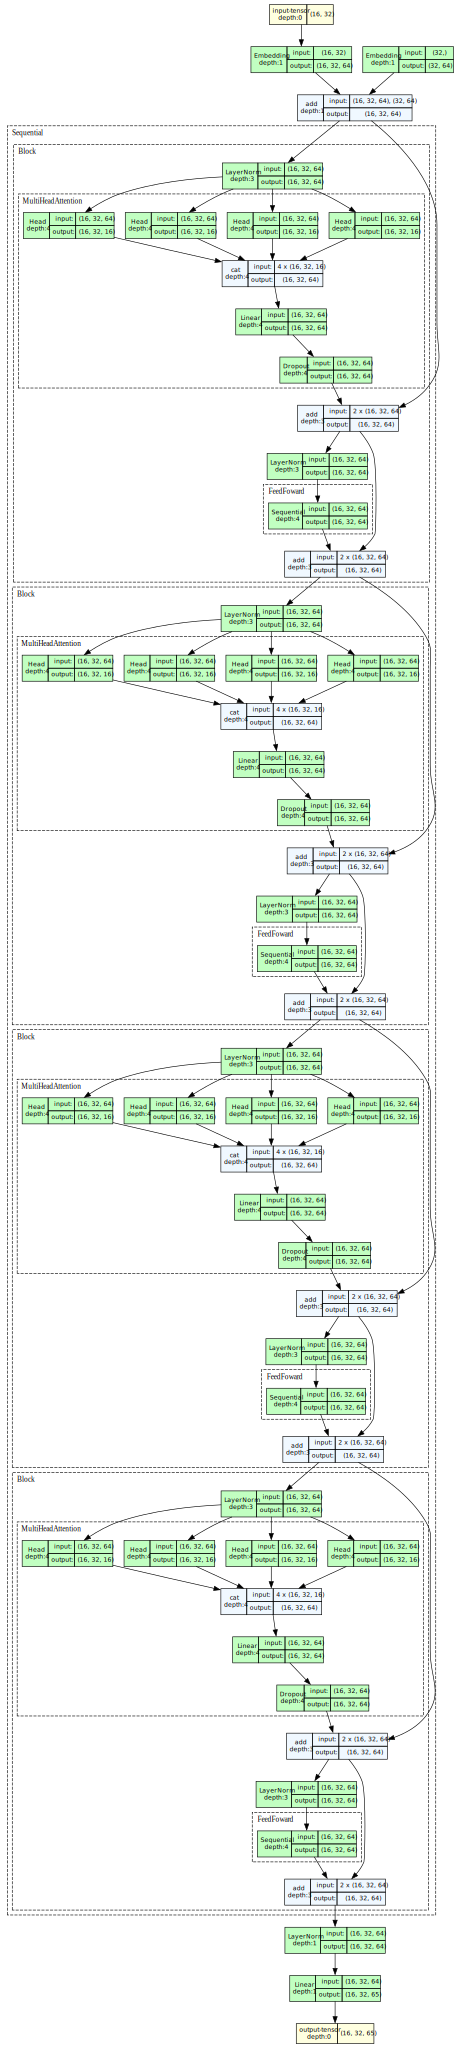

In [419]:
model_graph = draw_graph(
    m,
    input_data=dummy_idx,          # same integer token input as for torchinfo
    graph_name="nanoGPT",
    depth=4,                       # increase to 5 or 6 if you want more details
    expand_nested=True,
    roll=True
)
model_graph.visual_graph

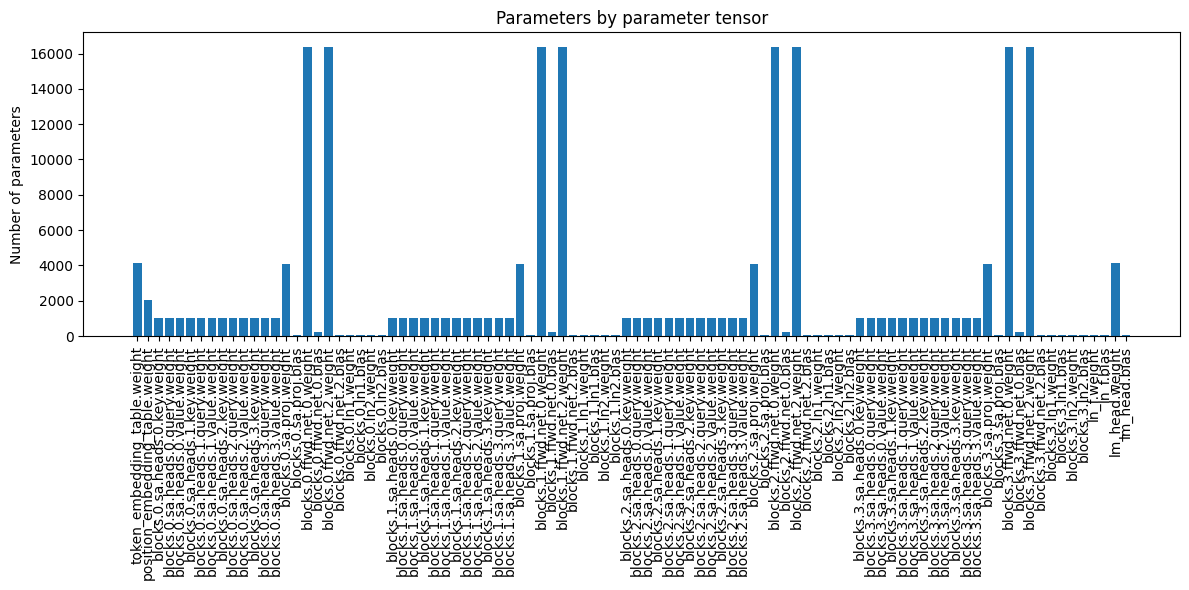

In [420]:
from collections import OrderedDict

# Count parameters by full parameter name
param_counts = OrderedDict((name, p.numel()) for name, p in m.named_parameters())

plt.figure(figsize=(12, 6))
plt.bar(range(len(param_counts)), list(param_counts.values()))
plt.xticks(range(len(param_counts)), list(param_counts.keys()), rotation=90)
plt.ylabel("Number of parameters")
plt.title("Parameters by parameter tensor")
plt.tight_layout()
plt.show()

# For the **final model in your notebook**, the total number of **trainable parameters** is

$$
\boxed{209729}.
$$

Here is the breakdown.

<font color='red'>
    
## 1. Token embedding table
</font>

The model has `nn.Embedding(vocab_size, n_embd)` that is, $\text{nn.Embedding}(65,64)$. So the number of parameters is $65 \times 64 = 4160$.

<font color='red'>
    
## 2. Positional embedding table
</font>

The model also has  `nn.Embedding(block_size, n_embd)` that is, 
$\text{nn.Embedding}(32,64)$. So this gives $32 \times 64 = 2048$ parameters.

<font color='red'>
    
## 3. One Transformer block
</font>

**There are $n_{\text{layer}} = 4$ blocks.** **Each block contains: one multi-head self-attention module, one feed-forward network, two LayerNorms.**

<font color='teal'>
    
### (a) Self-attention
</font>

You have $n_{\text{embd}} = 64, n_{\text{head}} = 4,$ so each head has size $d_k = \frac{64}{4} = 16$.

For **one head**: key = $64 \times 16 = 1024$; query = $64 \times 16 = 1024$ and value = $64 \times 16 = 1024$. So one head has $1024 + 1024 + 1024 = 3072$ parameters. With 4 heads $4 \times 3072 = 12288$.

Then the output projection is $\text{nn.Linear}(64,64)$ which has $64 \times 64 + 64 = 4096 + 64 = 4160$ parameters. So the whole self-attention module has $12288 + 4160 = 16448.$

$$
\mathrm{SelfAttention}(X)=\mathrm{Concat}\!\left(\mathrm{softmax}\!\left(\frac{(XW_Q^{(h)})(XW_K^{(h)})^\top}{\sqrt{16}}\right)(XW_V^{(h)})\right)_{h=1}^4 W_O+b_O$$
$$
W_Q^{(h)},W_K^{(h)},W_V^{(h)}\in\mathbb{R}^{64\times 16},\;
W_O\in\mathbb{R}^{64\times 64},\; b_O\in\mathbb{R}^{64},
\quad
\#\mathrm{param}=4\big(64\cdot 16+64\cdot 16+64\cdot 16\big)+(64\cdot 64+64)=16448.
$$

<font color='teal'>
    
### (b) Feed-forward network
</font>

The feed-forward part is: $\text{Linear}(64,256)$; ReLU; $\text{Linear}(256,64)$.

First linear layer: $ 64 \times 256 + 256 = 16384 + 256 = 16640$. Second linear layer: $256 \times 64 + 64 = 16384 + 64 = 16448$

So feed-forward total: $16640 + 16448 = 33088$.

$$
y = W_2\,\mathrm{ReLU}(W_1x+b_1)+b_2,
\qquad
W_1\in\mathbb{R}^{256\times 64},\; b_1\in\mathbb{R}^{256},\; W_2\in\mathbb{R}^{64\times 256},\; b_2\in\mathbb{R}^{64},
\qquad
\#\mathrm{param} = 256\cdot 64 + 256 + 64\cdot 256 + 64 = 33088.
$$

<font color='teal'>
    
### (c) LayerNorms
</font>

Each LayerNorm on dimension 64 has:

- 64 scale parameters,
- 64 bias parameters.

So one LayerNorm has $64 + 64 = 128$ parameters.

There are 2 in each block, so: $2 \times 128 = 256$

$$
\mathrm{LayerNorm}(x)=\gamma \odot \frac{x-\mu(x)}{\sqrt{\sigma^2(x)+\varepsilon}}+\beta,
\qquad
\gamma,\beta\in\mathbb{R}^{64},
\qquad
\#\mathrm{param}=2\times(64+64)=256.
$$

<font color='teal'>
    
### (d) Total per block
</font>

So one block has $16448 + 33088 + 256 = 49792$ parameters. Since there are 4 blocks: $4 \times 49792 = 199168.$

<font color='red'>
    
## 4. Final LayerNorm
</font>

The final LayerNorm contributes again $64 + 64 = 128$ parameters.

<font color='red'>
    
## 5. Final language-model head
</font>


The final layer is $\text{nn.Linear}(64,65)$ so it has $64 \times 65 + 65 = 4160 + 65 = 4225$ parameters.

<font color='green'>
    
## 6. Total
</font>

Now add everything:

$$
4160 + 2048 + 199168 + 128 + 4225 = 209729.
$$

So the final answer is

$$
\boxed{209729}.
$$


___

<font color='teal'>

Notice that the trainable parameters come only from the learned layers:

- embedding tables,
- linear layers,
- LayerNorm scale and bias.

They do **not** come from:

- ReLU,
- dropout,
- softmax,
- the causal mask.

</font>

███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# (8) Additional work to do (inspired by chatGPT) 
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

___

<font color='black'>
    
Here are some natural extensions of this notebook.

### Additional exercises

1. **Effect of the context length**
   
   Train the final model with different values of `block_size`, for example:
   - `8`,
   - `16`,
   - `32`,
   - `64`.
   
   Study how validation loss changes.  
   Does a longer context always help?

2. **Effect of the embedding dimension**
   
   Test several values of `n_embd`, for example:
   - `32`,
   - `64`,
   - `128`.
   
   For each choice:
   - compute the number of parameters,
   - train the model,
   - compare train and validation losses.

3. **Effect of the number of heads**
   
   Keep `n_embd = 64`, and test:
   - `n_head = 1`,
   - `n_head = 2`,
   - `n_head = 4`,
   - `n_head = 8`.
   
   Explain how the head size
   $$
   d_k = \frac{n_{\mathrm{embd}}}{n_{\mathrm{head}}}
   $$
   changes, and how this affects the model.

4. **Effect of the number of Transformer blocks**
   
   Test:
   - `n_layer = 1`,
   - `n_layer = 2`,
   - `n_layer = 4`,
   - `n_layer = 6`.
   
   Plot validation loss as a function of depth.

5. **Add dropout**
   
   In the notebook, the final model uses `dropout = 0.0`.  
   Try:
   - `0.1`,
   - `0.2`,
   - `0.3`.
   
   Does dropout improve generalization on validation data?

6. **Attention visualization**
   
   For a small input sentence, save and display the attention matrix
   
   $$
   A = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right).
   $$
   
   Plot it with `matplotlib` and, if possible, interpret what each head attends to.

7. **Ablation study**
   
   Remove or modify one component at a time:
   - remove positional embeddings,
   - remove LayerNorm,
   - remove the feed-forward network,
   - remove the residual connection.
   
   Observe which components are most important.

8. **Sampling strategies for text generation**
   
   The notebook generates text by sampling from the softmax distribution.  
   Add:
   - **greedy decoding**,
   - **temperature sampling**,
   - **top-k sampling**.
   
   Compare the generated texts qualitatively.

9. **Training curves and overfitting**
    
    Train the model for longer and study:
    - training loss,
    - validation loss.
    
    At what point does overfitting start?



---

### Additional models to test

1. **Trigram or n-gram count model**
   
   Extend the count-based model from bigrams to trigrams:
   
   $$
   P(x_t \mid x_{t-2}, x_{t-1}).
   $$
   
   This gives a stronger classical baseline.

2. **MLP language model**
   
   Instead of attention, concatenate the embeddings of the previous tokens and feed them to a small MLP:
   
   $$
   x \mapsto \mathrm{MLP}(e_{t-k},\dots,e_{t-1}).
   $$
   
   This is a nice intermediate model between n-grams and Transformers.

3. **RNN / GRU / LSTM**
   
   Compare the Transformer with recurrent models:
   - vanilla RNN,
   - GRU,
   - LSTM.
   
   This is pedagogically very useful because it highlights the difference between:
   - recurrence,
   - attention,
   - fixed-size vs flexible context handling.

4. **Transformer without positional embeddings**
   
   Test the same architecture but remove
   
   $$
   x = \text{tok\_emb} + \text{pos\_emb}.
   $$
   
   This helps students understand why positional information is necessary.

5. **Transformer with sinusoidal positional encoding**
   
   Replace learned positional embeddings by deterministic sinusoidal encodings.  
   Then compare:
   - parameter count,
   - training speed,
   - validation loss.
